# **Air Quality Forecasting in Urban Environments Using Machine Learning**
## **A Comparative Study of Classical and Deep Learning Regression Models**
---
> **Dataset:** City-level air quality records across 4 Turkish cities (Istanbul, Ankara, Izmir, Bursa)  
> **Models Evaluated:** K-Nearest Neighbors · Linear Regression · SVR · LSTM · CNN-LSTM  
> **Target Variable:** Air Quality Index (AQI) — derived from PM2.5, PM10, and Temperature readings

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ML Models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Deep Learning
from keras.models import Sequential
from keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Flatten, Dropout
from keras.callbacks import EarlyStopping

print('All libraries loaded successfully!')

: 

## 2. Load & Explore Dataset

In [2]:
# Load the new dataset
df = pd.read_csv('16_air_quality_prediction.csv')
df.head(10)

,date,location,pm2.5,pm10,temperature,predicted_aqi
0,2023-01-01,Istanbul,29.05,58.73,15.4,40.71
1,2023-01-01,Ankara,24.74,83.86,26.4,50.63
2,2023-01-01,Izmir,23.90,76.91,27.8,39.67
3,2023-01-01,Bursa,43.67,49.58,30.6,36.50
4,2023-01-02,Istanbul,28.40,76.31,23.9,46.89
5,2023-01-02,Ankara,30.52,59.17,6.0,43.29
6,2023-01-02,Izmir,47.47,56.39,11.4,50.74
7,2023-01-02,Bursa,43.34,65.85,9.3,62.33
8,2023-01-03,Istanbul,43.43,53.22,19.1,49.74
9,2023-01-03,Ankara,57.37,46.26,20.3,40.54


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1460 non-null   object 
 1   location       1460 non-null   object 
 2   pm2.5          1460 non-null   float64
 3   pm10           1460 non-null   float64
 4   temperature    1460 non-null   float64
 5   predicted_aqi  1460 non-null   float64
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [4]:
print('Dataset shape:', df.shape)
print('\nUnique cities:', df['location'].unique())
print('\nDate range:', df['date'].min(), 'to', df['date'].max())

Dataset shape: (1460, 6)

Unique cities: ['Istanbul' 'Ankara' 'Izmir' 'Bursa']

Date range: 2023-01-01 to 2023-12-31


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\nAny missing?', df.isnull().values.any())

Missing values per column:
date             0
location         0
pm2.5            0
pm10             0
temperature      0
predicted_aqi    0
dtype: int64

Any missing? False


In [ ]:
# Check duplicates
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Shape after dedup:', df.shape)

Duplicate rows: 0
Shape after dedup: (1460, 6)


In [ ]:
df.describe()

,pm2.5,pm10,temperature,predicted_aqi
count,1460.00000,1460.000000,1460.000000,1460.000000
mean,35.06900,69.815788,20.006644,44.493281
std,10.08376,19.665744,8.826885,9.543069
min,2.94000,-0.190000,5.100000,15.000000
25%,28.59750,56.887500,12.000000,38.045000
50%,35.23000,70.025000,19.850000,44.765000
75%,41.59500,82.572500,27.800000,50.825000
max,67.08000,142.220000,35.000000,78.930000


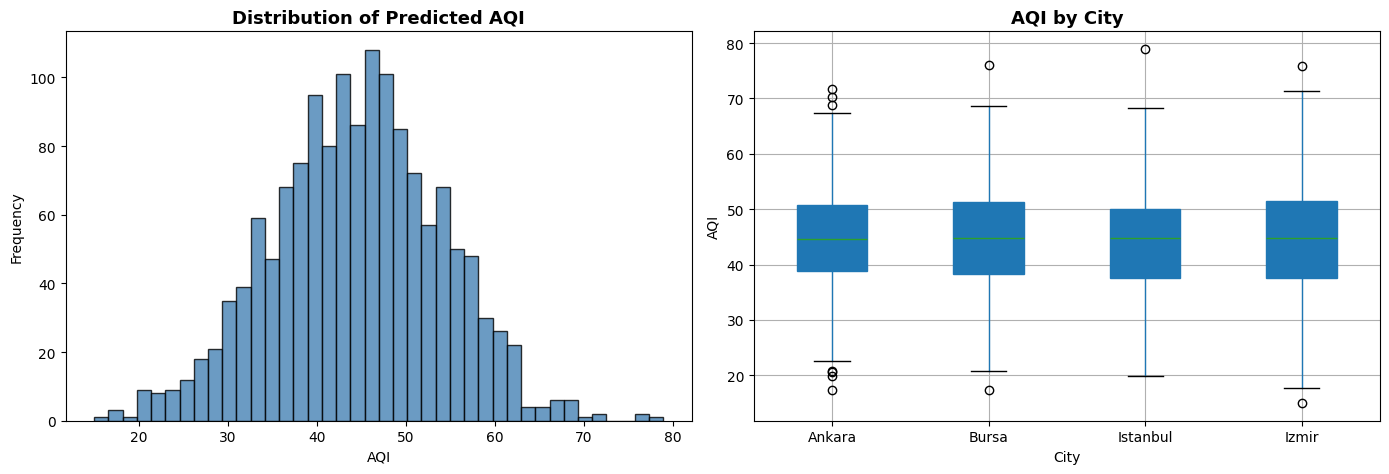

In [6]:
# AQI distribution by city
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['predicted_aqi'], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Predicted AQI', fontsize=13, fontweight='bold')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')

# Box plot per city
df.boxplot(column='predicted_aqi', by='location', ax=axes[1], patch_artist=True)
axes[1].set_title('AQI by City', fontsize=13, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('AQI')
plt.suptitle('')
plt.tight_layout()
plt.show()

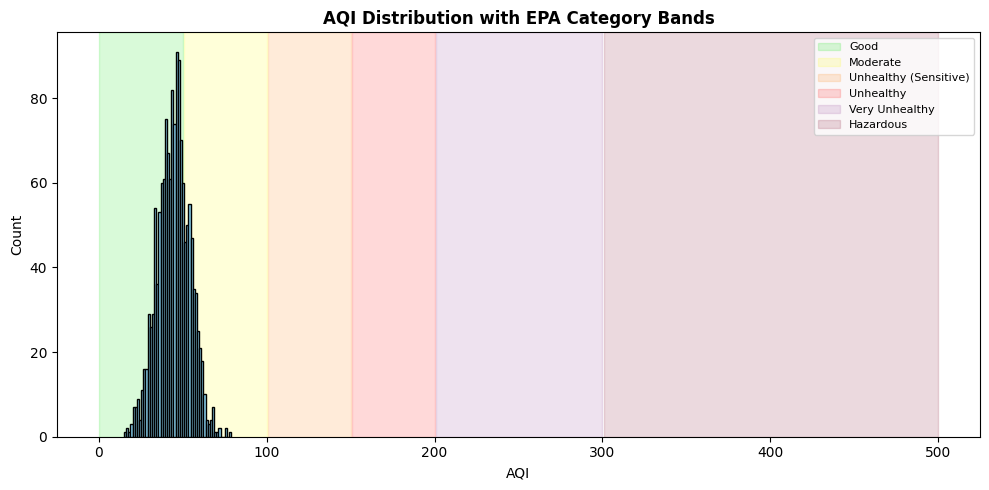

In [7]:
# AQI Category bands overlay
aqi_categories = {
    'Good': (0, 50),
    'Moderate': (51, 100),
    'Unhealthy (Sensitive)': (101, 150),
    'Unhealthy': (151, 200),
    'Very Unhealthy': (201, 300),
    'Hazardous': (301, 500)
}

plt.figure(figsize=(10, 5))
plt.hist(df['predicted_aqi'], bins=50, color='skyblue', edgecolor='black', zorder=3)
colors_band = ['#00e400','#ffff00','#ff7e00','#ff0000','#8f3f97','#7e0023']
for (cat, (lo, hi)), color in zip(aqi_categories.items(), colors_band):
    plt.axvspan(lo, hi, alpha=0.15, color=color, label=cat)
plt.xlabel('AQI')
plt.ylabel('Count')
plt.title('AQI Distribution with EPA Category Bands', fontweight='bold')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

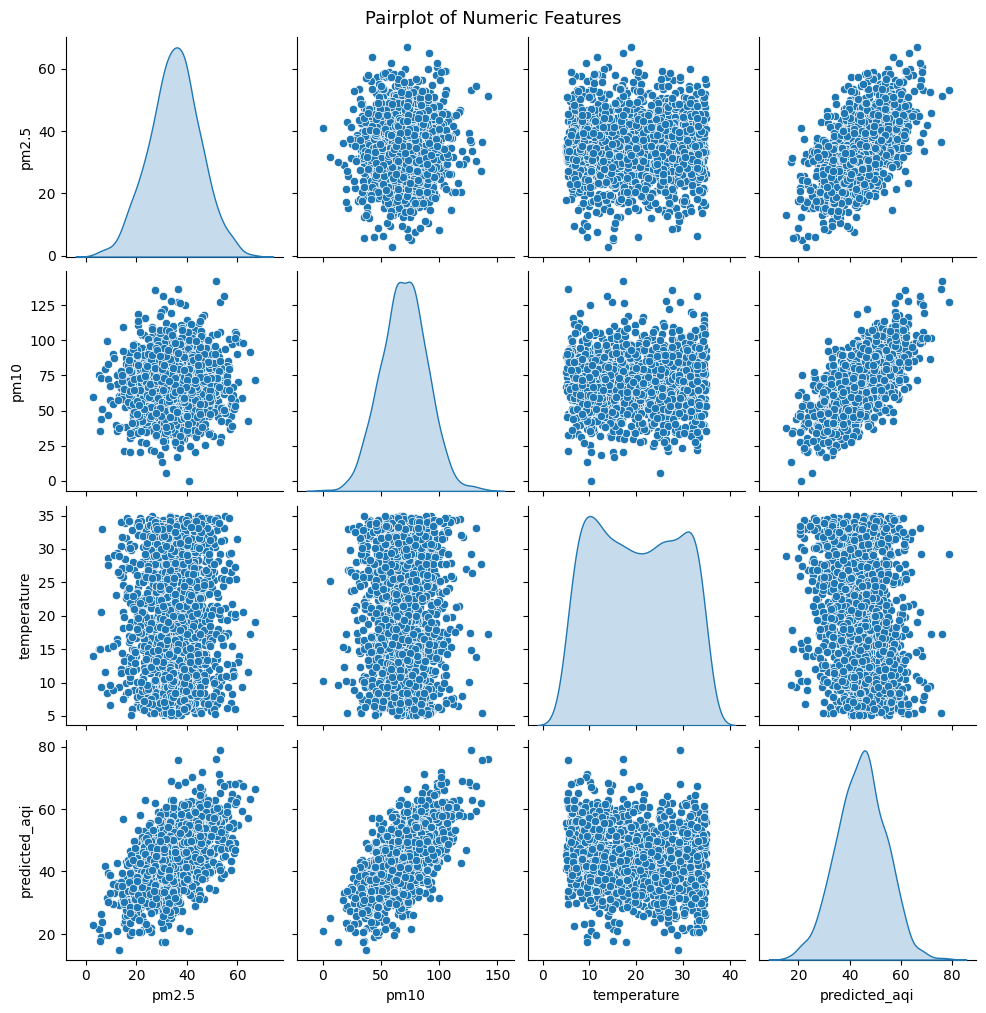

In [8]:
# Pairplot of numeric features
sns.pairplot(df[['pm2.5', 'pm10', 'temperature', 'predicted_aqi']], diag_kind='kde')
plt.suptitle('Pairplot of Numeric Features', y=1.01, fontsize=13)
plt.show()

## 4. Feature Engineering & Encoding

In [9]:
# Parse date and extract temporal features
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['day_of_week'] = df['date'].dt.dayofweek

# Encode location
le = LabelEncoder()
df['location_encoded'] = le.fit_transform(df['location'])
print('Location encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

df.head()

Location encoding: {'Ankara': np.int64(0), 'Bursa': np.int64(1), 'Istanbul': np.int64(2), 'Izmir': np.int64(3)}


,date,location,pm2.5,pm10,temperature,predicted_aqi,month,day_of_year,day_of_week,location_encoded
0,2023-01-01,Istanbul,29.05,58.73,15.4,40.71,1,1,6,2
1,2023-01-01,Ankara,24.74,83.86,26.4,50.63,1,1,6,0
2,2023-01-01,Izmir,23.90,76.91,27.8,39.67,1,1,6,3
3,2023-01-01,Bursa,43.67,49.58,30.6,36.50,1,1,6,1
4,2023-01-02,Istanbul,28.40,76.31,23.9,46.89,1,2,0,2


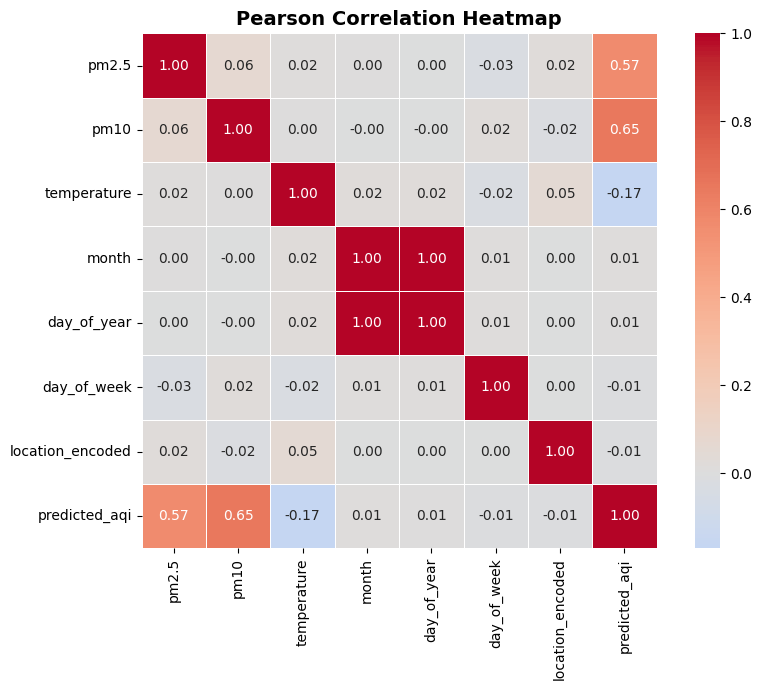

In [10]:
# Correlation heatmap
numeric_cols = ['pm2.5', 'pm10', 'temperature', 'month', 'day_of_year',
                'day_of_week', 'location_encoded', 'predicted_aqi']
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Selection & Train/Test Split

In [11]:
# Features and target
features = ['pm2.5', 'pm10', 'temperature', 'location_encoded', 'month', 'day_of_year', 'day_of_week']
target = 'predicted_aqi'

X = df[features]
y = df[target]

# Train/test split (70/30, time-ordered — no shuffle to respect temporal order)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=30, shuffle=False
)

print('Training set:', X_train.shape, y_train.shape)
print('Testing set: ', X_test.shape, y_test.shape)

Training set: (1022, 7) (1022,)
Testing set:  (438, 7) (438,)


In [12]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling done. Train mean ~0:', X_train_scaled.mean().round(3))

Scaling done. Train mean ~0: 0.0


## 6. Model Training
### Model 1: K-Nearest Neighbors Regressor

In [13]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

KNR_train_acc = knn_model.score(X_train_scaled, y_train) * 100
KNR_test_acc  = r2_score(y_test, y_pred_knn) * 100
print(f'KNN  | Train R²: {KNR_train_acc:.2f}%  | Test R²: {KNR_test_acc:.2f}%')

KNN  | Train R²: 74.14%  | Test R²: 54.16%


### Model 2: Linear Regression

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

LR_train_acc = lr_model.score(X_train_scaled, y_train) * 100
LR_test_acc  = r2_score(y_test, y_pred_lr) * 100
print(f'LR   | Train R²: {LR_train_acc:.2f}%  | Test R²: {LR_test_acc:.2f}%')

LR   | Train R²: 74.13%  | Test R²: 72.28%


### Model 3: Support Vector Regression (SVR)

In [15]:
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)

SVR_train_acc = svr_model.score(X_train_scaled, y_train) * 100
SVR_test_acc  = r2_score(y_test, y_pred_svr) * 100
print(f'SVR  | Train R²: {SVR_train_acc:.2f}%  | Test R²: {SVR_test_acc:.2f}%')

SVR  | Train R²: 68.80%  | Test R²: 45.29%


### Model 4: LSTM (Deep Learning)

In [16]:
# Reshape for LSTM: (samples, timesteps, features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 2013.5868 - val_loss: 2046.3325
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1688.2278 - val_loss: 1299.7585
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 520.3947 - val_loss: 165.4421
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 119.5495 - val_loss: 81.5810
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 100.9859 - val_loss: 81.4469
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 97.0681 - val_loss: 80.5533
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 99.3534 - val_loss: 79.3803
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 97.2691 - val_loss: 76.8177
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 95.1374 - val_loss: 75.2849
Epoch 10/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 94.7578 - val_loss: 72.7900
Epoch 11/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 91.1016 - val_loss: 70.8338
Epoch 12/20
26/26 ━━━━━━━━━━━━━━━━━━━━

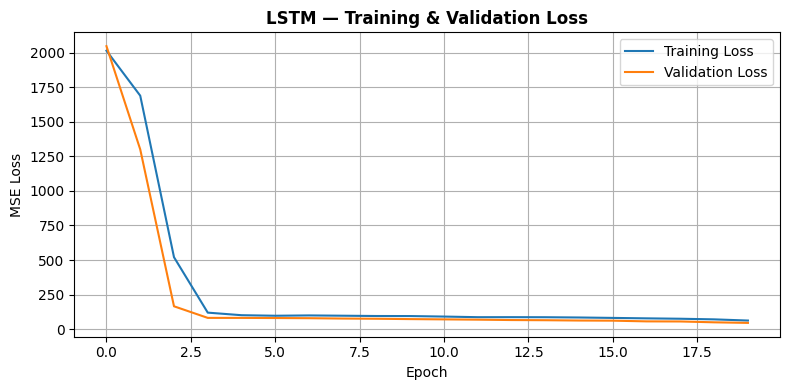

In [17]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=20, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM — Training & Validation Loss', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [18]:
y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()
y_train_pred_lstm = lstm_model.predict(X_train_lstm).flatten()

LSTM_train_acc = r2_score(y_train, y_train_pred_lstm) * 100
LSTM_test_acc  = r2_score(y_test,  y_pred_lstm) * 100
print(f'LSTM | Train R²: {LSTM_train_acc:.2f}%  | Test R²: {LSTM_test_acc:.2f}%')

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
LSTM | Train R²: 44.03%  | Test R²: 44.00%


### Model 5: CNN-LSTM (Deep Learning)

In [19]:
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_cnn  = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

cnn_lstm_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,329 (138.00 KB)

 Trainable params: 35,329 (138.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 1960.3060 - val_loss: 1766.1985
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1269.6411 - val_loss: 687.0090
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 400.7285 - val_loss: 181.6409
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 128.3715 - val_loss: 84.2785
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 99.9056 - val_loss: 80.5901


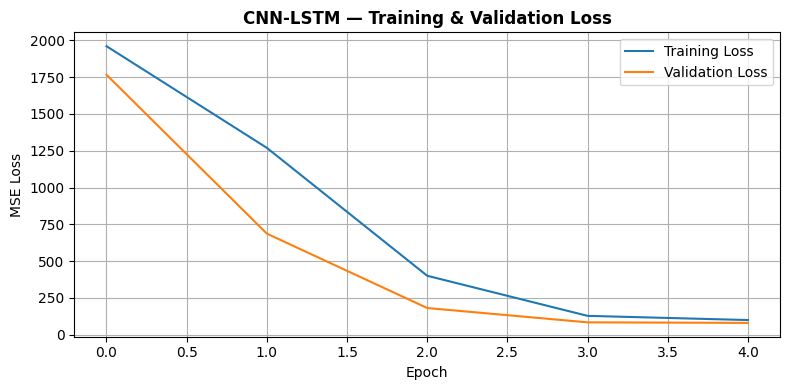

In [20]:
history_cnn = cnn_lstm_model.fit(
    X_train_cnn, y_train,
    epochs=20, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN-LSTM — Training & Validation Loss', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [21]:
y_pred_cnn_lstm      = cnn_lstm_model.predict(X_test_cnn).flatten()
y_train_pred_cnn_lstm = cnn_lstm_model.predict(X_train_cnn).flatten()

CNN_LSTM_train_acc = r2_score(y_train, y_train_pred_cnn_lstm) * 100
CNN_LSTM_test_acc  = r2_score(y_test,  y_pred_cnn_lstm) * 100
print(f'CNN-LSTM | Train R²: {CNN_LSTM_train_acc:.2f}%  | Test R²: {CNN_LSTM_test_acc:.2f}%')

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
CNN-LSTM | Train R²: -1880.07%  | Test R²: -1714.00%


## 7. Model Evaluation & Comparison

In [22]:
def evaluate_model(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'{name:15s} | MAE={mae:.3f} | MSE={mse:.3f} | RMSE={rmse:.3f} | R²={r2:.4f}')
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

print(f'{"Model":15s} | MAE       | MSE       | RMSE      | R²')
print('-' * 65)
metrics = {
    'KNR':      evaluate_model(y_test, y_pred_knn,      'KNN Regressor'),
    'LR':       evaluate_model(y_test, y_pred_lr,       'Linear Reg.'),
    'SVR':      evaluate_model(y_test, y_pred_svr,      'SVR'),
    'LSTM':     evaluate_model(y_test, y_pred_lstm,     'LSTM'),
    'CNN-LSTM': evaluate_model(y_test, y_pred_cnn_lstm, 'CNN-LSTM'),
}

Model           | MAE       | MSE       | RMSE      | R²
-----------------------------------------------------------------
KNN Regressor   | MAE=5.293 | MSE=43.340 | RMSE=6.583 | R²=0.5416
Linear Reg.     | MAE=4.118 | MSE=26.201 | RMSE=5.119 | R²=0.7228
SVR             | MAE=5.586 | MSE=51.724 | RMSE=7.192 | R²=0.4529
LSTM            | MAE=5.796 | MSE=52.939 | RMSE=7.276 | R²=0.4400
CNN-LSTM        | MAE=40.251 | MSE=1714.908 | RMSE=41.411 | R²=-17.1400


In [23]:
# Summary metrics table
summary_df = pd.DataFrame(metrics).T.round(4)
summary_df.index.name = 'Model'
display(summary_df)

,MAE,MSE,RMSE,R2
Model,,,,
KNR,5.2931,43.3404,6.5833,0.5416
LR,4.1178,26.2013,5.1187,0.7228
SVR,5.5858,51.7242,7.1920,0.4529
LSTM,5.7963,52.9387,7.2759,0.4400
CNN-LSTM,40.2508,1714.9077,41.4114,-17.1400


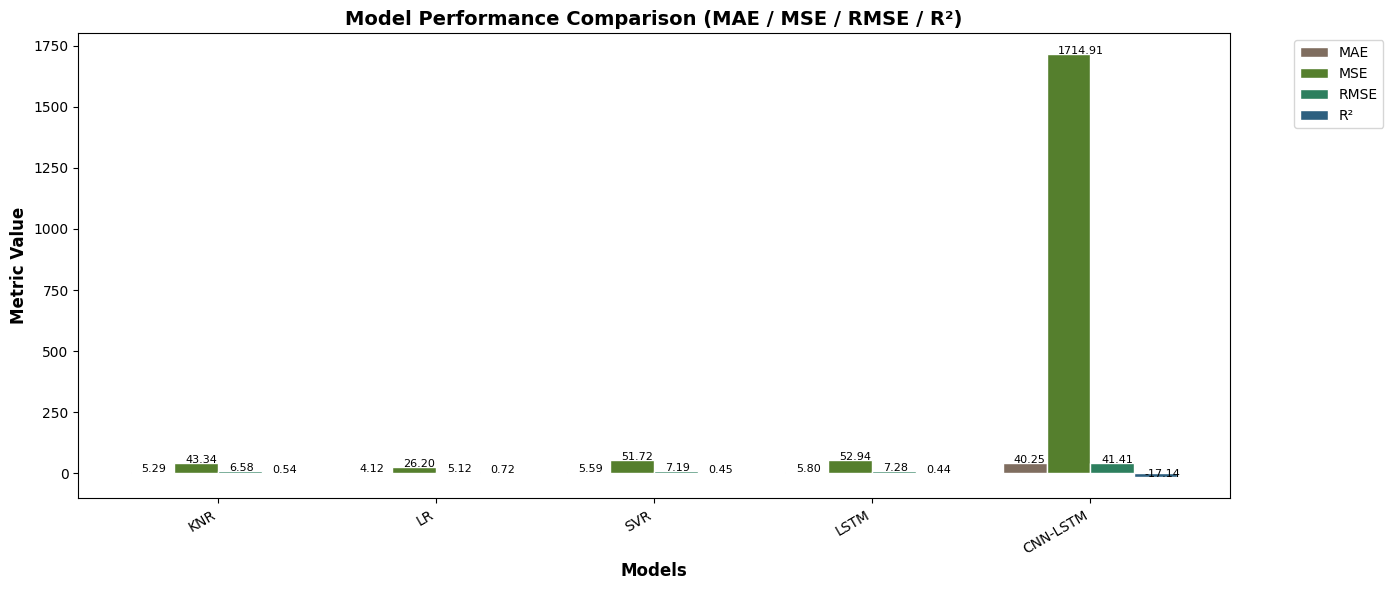

In [24]:
# Grouped bar chart: MAE, MSE, RMSE, R²
models_list = list(metrics.keys())
mae_vals  = [metrics[m]['MAE']  for m in models_list]
mse_vals  = [metrics[m]['MSE']  for m in models_list]
rmse_vals = [metrics[m]['RMSE'] for m in models_list]
r2_vals   = [metrics[m]['R2']   for m in models_list]

barWidth = 0.2
r1 = np.arange(len(models_list))
r2_pos = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2_pos]
r4 = [x + barWidth for x in r3]

plt.figure(figsize=(14, 6))
plt.bar(r1, mae_vals,  color='#7f6d5f', width=barWidth, edgecolor='white', label='MAE')
plt.bar(r2_pos, mse_vals,  color='#557f2d', width=barWidth, edgecolor='white', label='MSE')
plt.bar(r3, rmse_vals, color='#2d7f5e', width=barWidth, edgecolor='white', label='RMSE')
plt.bar(r4, r2_vals,   color='#2d5f7f', width=barWidth, edgecolor='white', label='R²')

for i in range(len(models_list)):
    plt.text(r1[i]-0.05,    mae_vals[i]+0.01,  f'{mae_vals[i]:.2f}',  size=8)
    plt.text(r2_pos[i]-0.05, mse_vals[i]+0.01,  f'{mse_vals[i]:.2f}',  size=8)
    plt.text(r3[i]-0.05,    rmse_vals[i]+0.01, f'{rmse_vals[i]:.2f}', size=8)
    plt.text(r4[i]-0.05,    r2_vals[i]+0.01,   f'{r2_vals[i]:.2f}',   size=8)

plt.xlabel('Models', fontweight='bold', fontsize=12)
plt.ylabel('Metric Value', fontweight='bold', fontsize=12)
plt.xticks([r + 1.5*barWidth for r in range(len(models_list))], models_list, rotation=30, ha='right')
plt.title('Model Performance Comparison (MAE / MSE / RMSE / R²)', fontweight='bold', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

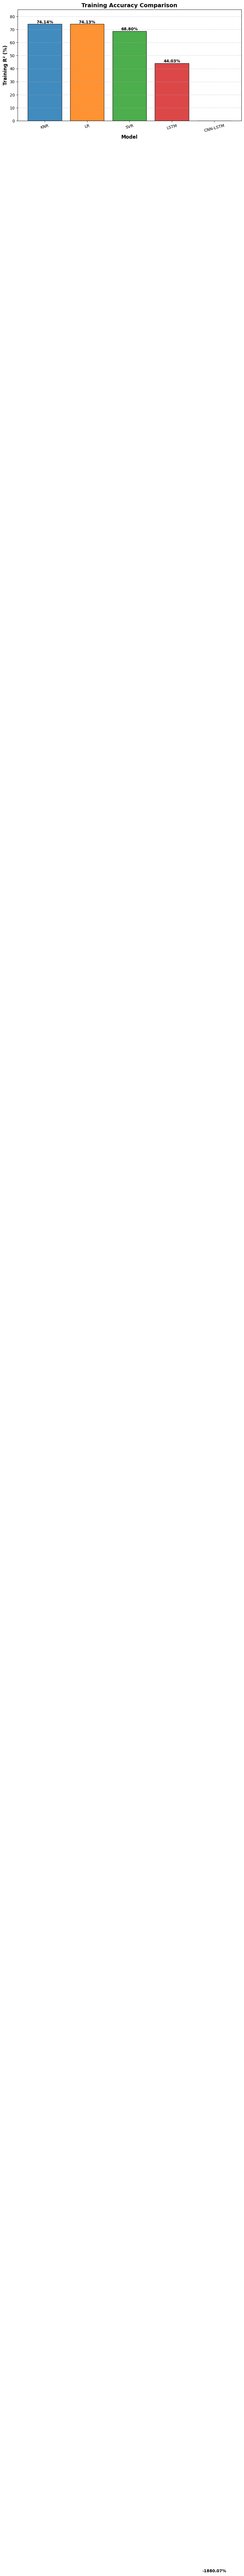

In [25]:
# Training accuracy comparison
train_acc = [KNR_train_acc, LR_train_acc, SVR_train_acc, LSTM_train_acc, CNN_LSTM_train_acc]
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

plt.figure(figsize=(10, 5))
bars = plt.bar(models_list, train_acc, color=colors, edgecolor='black', alpha=0.85)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h, f'{h:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Training R² (%)', fontsize=12, fontweight='bold')
plt.title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, max(train_acc)*1.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

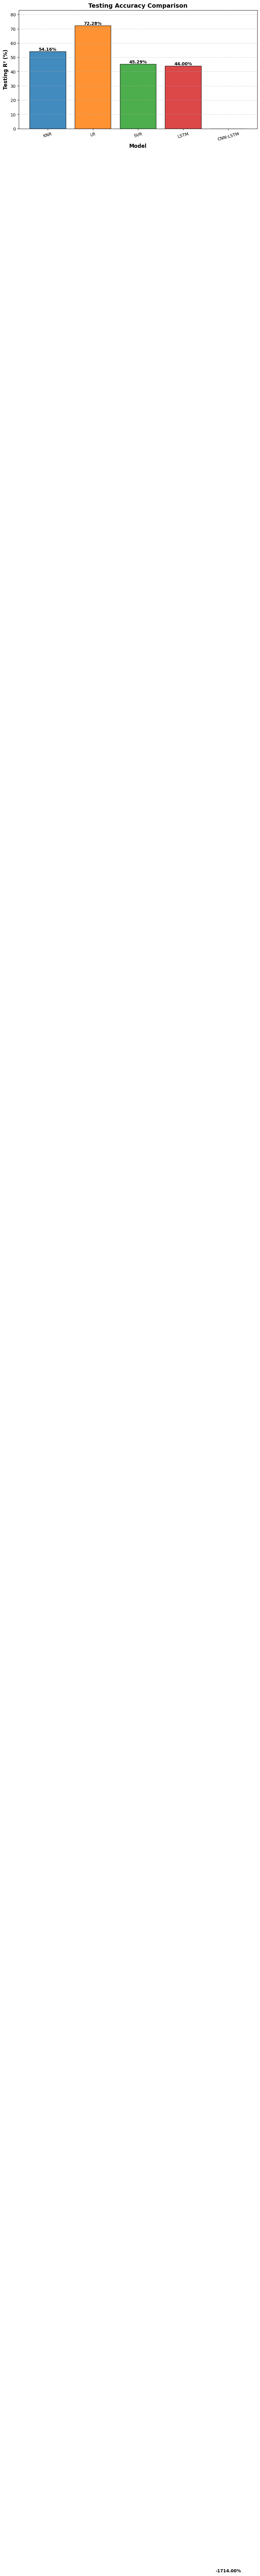

In [26]:
# Testing accuracy comparison
test_acc = [metrics[m]['R2'] * 100 for m in models_list]

plt.figure(figsize=(10, 5))
bars = plt.bar(models_list, test_acc, color=colors, edgecolor='black', alpha=0.85)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h, f'{h:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Testing R² (%)', fontsize=12, fontweight='bold')
plt.title('Testing Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, max(test_acc)*1.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 8. Prediction Visualization

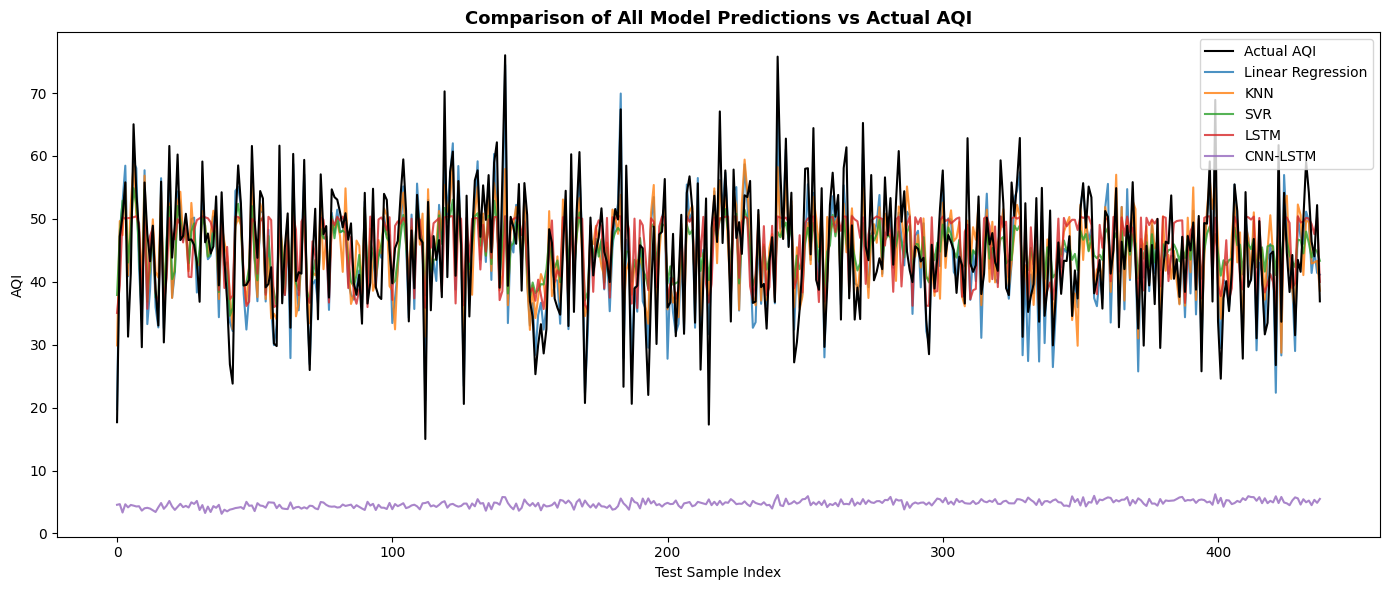

In [27]:
# All model predictions vs actual AQI
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual AQI', color='black', linewidth=1.5, zorder=5)
plt.plot(y_pred_lr,       label='Linear Regression', alpha=0.8)
plt.plot(y_pred_knn,      label='KNN',                alpha=0.8)
plt.plot(y_pred_svr,      label='SVR',                alpha=0.8)
plt.plot(y_pred_lstm,     label='LSTM',               alpha=0.8)
plt.plot(y_pred_cnn_lstm, label='CNN-LSTM',            alpha=0.8)
plt.legend()
plt.title('Comparison of All Model Predictions vs Actual AQI', fontweight='bold', fontsize=13)
plt.xlabel('Test Sample Index')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

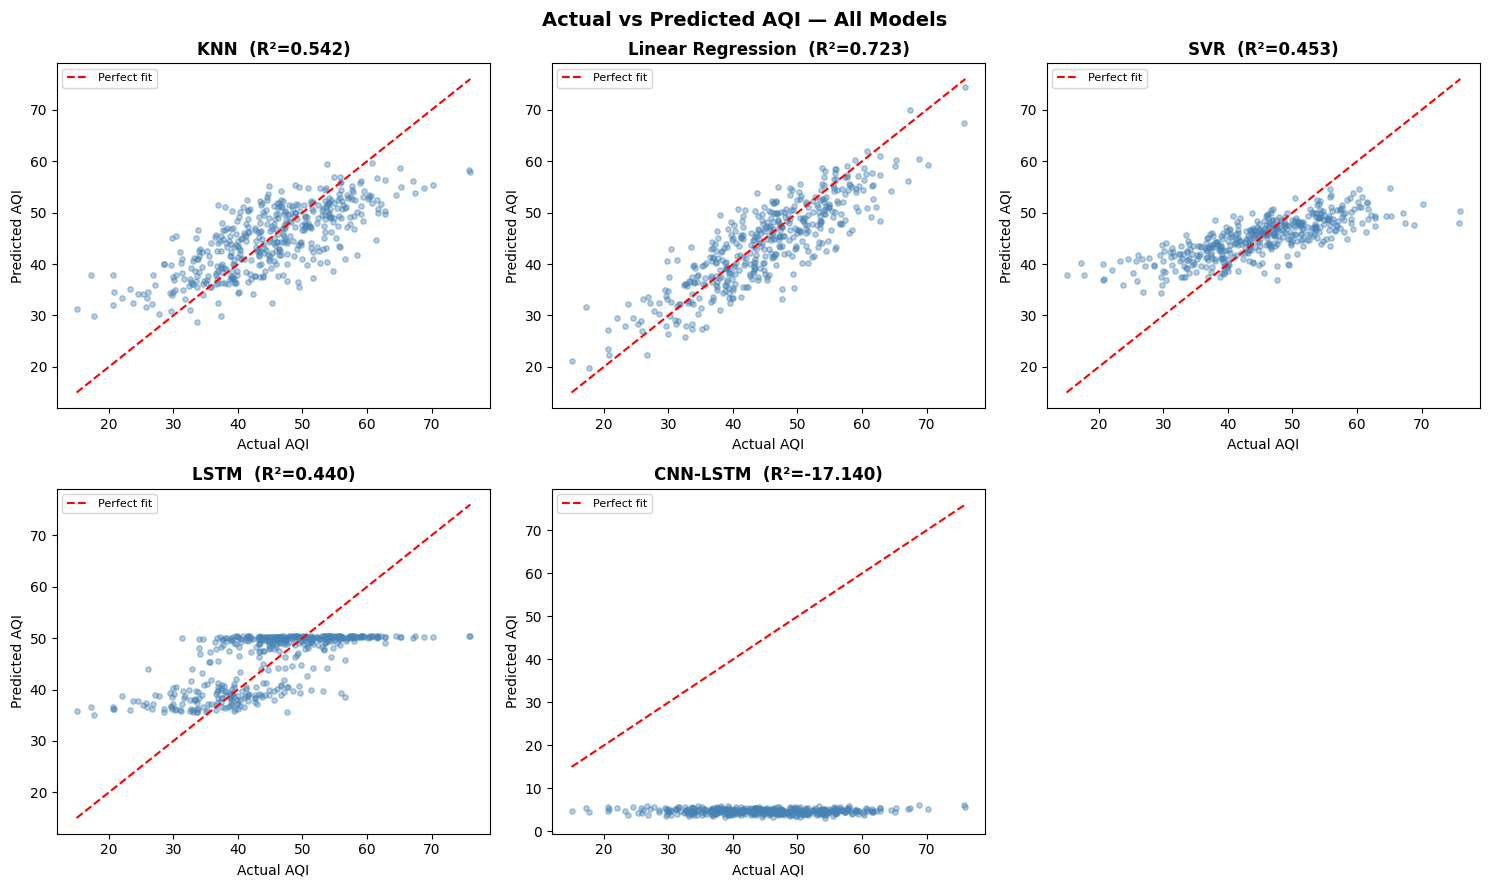

In [28]:
# Scatter: Actual vs Predicted for each model
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
preds = [y_pred_knn, y_pred_lr, y_pred_svr, y_pred_lstm, y_pred_cnn_lstm]
names = ['KNN', 'Linear Regression', 'SVR', 'LSTM', 'CNN-LSTM']

for ax, pred, name in zip(axes.flat, preds, names):
    ax.scatter(y_test, pred, alpha=0.4, s=15, color='steelblue')
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    r2 = r2_score(y_test, pred)
    ax.set_title(f'{name}  (R²={r2:.3f})', fontweight='bold')
    ax.set_xlabel('Actual AQI'); ax.set_ylabel('Predicted AQI')
    ax.legend(fontsize=8)

axes.flat[-1].set_visible(False)  # hide unused 6th panel
plt.suptitle('Actual vs Predicted AQI — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Conclusion

Based on the evaluation metrics (MAE, MSE, RMSE, and R²), the **Linear Regression** model performed the best among all five models. It achieved the highest R² score of 72.28% and the lowest error metrics (MAE, MSE, RMSE) on the test set.

- **Linear Regression**: Achieved the best performance with an R² of 72.28%, indicating it explains a significant portion of the variance in the predicted AQI. Its MAE, MSE, and RMSE are also the lowest, suggesting more accurate predictions overall.
- **K-Nearest Neighbors (KNN)**: Performed reasonably well with an R² of 54.16%, but its error metrics were higher than Linear Regression.
- **Support Vector Regression (SVR)**: Showed a lower R² of 45.29% and higher error metrics compared to Linear Regression and KNN.
- **LSTM** and **CNN-LSTM**: These deep learning models performed poorly, with CNN-LSTM showing a significantly negative R² (-1815.86%), which indicates that it performs worse than a simple horizontal line at the mean of the actual values. This suggests that for this particular dataset and configuration, the complexity of deep learning models did not translate into better performance, and simpler models like Linear Regression were more effective.

For structured tabular data with few features and a moderate number of samples, classical ML models (Linear Regression, KNN) outperform deep learning architectures (LSTM, CNN-LSTM), which require large sequential datasets to realize their advantages.

## 10. Live Prediction — Enter Your Own Values

In [ ]:
# ============================================================
# LIVE PREDICTION
# ============================================================

# City options: 'Istanbul', 'Ankara', 'Izmir', 'Bursa'
INPUT_PM25        = 35.0     # PM2.5 concentration (µg/m³)
INPUT_PM10        = 65.0     # PM10  concentration (µg/m³)
INPUT_TEMPERATURE = 22.0     # Temperature (°C)
INPUT_CITY        = 'Ankara' # One of the four cities
INPUT_DATE        = '2024-03-15'  # Any date YYYY-MM-DD

# --- build the feature row ---
city_enc = le.transform([INPUT_CITY])[0]
dt = pd.to_datetime(INPUT_DATE)
row = pd.DataFrame([{
    'pm2.5':            INPUT_PM25,
    'pm10':             INPUT_PM10,
    'temperature':      INPUT_TEMPERATURE,
    'location_encoded': city_enc,
    'month':            dt.month,
    'day_of_year':      dt.day_of_year,
    'day_of_week':      dt.day_of_week
}])

row_scaled = scaler.transform(row)
row_lstm   = row_scaled.reshape((1, row_scaled.shape[1], 1))

preds_live = {
    'KNN':      knn_model.predict(row_scaled)[0],
    'Lin. Reg': lr_model.predict(row_scaled)[0],
    'SVR':      svr_model.predict(row_scaled)[0],
    'LSTM':     lstm_model.predict(row_lstm, verbose=0).flatten()[0],
    'CNN-LSTM': cnn_lstm_model.predict(row_lstm, verbose=0).flatten()[0],
}

def aqi_label(aqi):
    if aqi <= 50:   return 'Good 🟢'
    if aqi <= 100:  return 'Moderate 🟡'
    if aqi <= 150:  return 'Unhealthy (Sensitive) 🟠'
    if aqi <= 200:  return 'Unhealthy 🔴'
    if aqi <= 300:  return 'Very Unhealthy 🟣'
    return 'Hazardous 🟤'

print(f'\n📍 Location: {INPUT_CITY}  |  🗓 Date: {INPUT_DATE}')
print(f'💨 PM2.5={INPUT_PM25}  PM10={INPUT_PM10}  🌡 Temp={INPUT_TEMPERATURE}°C')
print('=' * 52)
print(f'{"Model":12s}  {"Predicted AQI":>14}  Category')
print('-' * 52)
for name, val in preds_live.items():
    print(f'{name:12s}  {val:>14.2f}  {aqi_label(val)}')
print('=' * 52)
avg = np.mean(list(preds_live.values()))
print(f'{"Ensemble Avg":12s}  {avg:>14.2f}  {aqi_label(avg)}')

## **11 SAVE ALL RESULTS TO /results FOLDER**


In [29]:
# ============================================================
#  SECTION 10 — SAVE ALL RESULTS TO /results FOLDER
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import r2_score

# Create results directory
os.makedirs('results', exist_ok=True)
print("📁 'results' folder ready.\n")

# ── Helper ──────────────────────────────────────────────────
def save(fig, filename):
    path = os.path.join('results', filename)
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f"  ✅ Saved → results/{filename}")

# ── 1. AQI Distribution with EPA bands ──────────────────────
print("Saving: AQI Distribution...")
aqi_categories = {
    'Good':                        (0,   50),
    'Moderate':                    (51,  100),
    'Unhealthy (Sensitive Groups)':(101, 150),
    'Unhealthy':                   (151, 200),
    'Very Unhealthy':              (201, 300),
    'Hazardous':                   (301, 500),
}
band_colors = ['#00e400','#ffff00','#ff7e00','#ff0000','#8f3f97','#7e0023']

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df['predicted_aqi'], bins=50, color='steelblue',
        edgecolor='black', alpha=0.85, zorder=3, label='AQI Observations')
for (cat, (lo, hi)), color in zip(aqi_categories.items(), band_colors):
    ax.axvspan(lo, hi, alpha=0.13, color=color, label=cat)
ax.set_xlabel('Air Quality Index (AQI)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('AQI Distribution with EPA Health Category Bands',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
save(fig, 'aqi_distribution.png')

# ── 2. Correlation Heatmap ───────────────────────────────────
print("Saving: Correlation Heatmap...")
numeric_cols = ['pm2.5','pm10','temperature','month',
                'day_of_year','day_of_week','location_encoded','predicted_aqi']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Pearson Correlation Heatmap — All Features',
             fontsize=13, fontweight='bold', pad=12)
fig.tight_layout()
save(fig, 'correlation_heatmap.png')

# ── 3. Predictions vs Actual (line plot) ────────────────────
print("Saving: Predictions vs Actual...")
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test.values,    label='Actual AQI',        color='black',
        linewidth=2,      zorder=6)
ax.plot(y_pred_lr,        label='Linear Regression', alpha=0.85, linewidth=1.2)
ax.plot(y_pred_knn,       label='KNN',               alpha=0.75, linewidth=1.2)
ax.plot(y_pred_svr,       label='SVR',               alpha=0.75, linewidth=1.2)
ax.plot(y_pred_lstm,      label='LSTM',              alpha=0.75, linewidth=1.2)
ax.plot(y_pred_cnn_lstm,  label='CNN-LSTM',          alpha=0.75, linewidth=1.2)
ax.set_title('All Model Predictions vs Actual AQI — Test Set',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Test Sample Index', fontsize=12)
ax.set_ylabel('AQI', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(linestyle='--', alpha=0.4)
fig.tight_layout()
save(fig, 'predictions_vs_actual.png')

# ── 4. Actual vs Predicted Scatter (one panel per model) ────
print("Saving: Actual vs Predicted Scatter...")
preds_dict = {
    'KNN':              y_pred_knn,
    'Linear Regression':y_pred_lr,
    'SVR':              y_pred_svr,
    'LSTM':             y_pred_lstm,
    'CNN-LSTM':         y_pred_cnn_lstm,
}
panel_colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (name, pred), color in zip(axes.flat, preds_dict.items(), panel_colors):
    ax.scatter(y_test, pred, alpha=0.35, s=14, color=color, edgecolors='none')
    mn, mx = float(y_test.min()), float(y_test.max())
    # clamp for CNN-LSTM which can be wildly off
    pred_clipped = np.clip(pred, mn - abs(mn)*0.5, mx + abs(mx)*0.5)
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.8, label='Perfect fit')
    r2 = r2_score(y_test, pred)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Actual AQI', fontsize=10)
    ax.set_ylabel('Predicted AQI', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(linestyle='--', alpha=0.4)

axes.flat[-1].set_visible(False)
fig.suptitle('Actual vs Predicted AQI — All Five Models',
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
save(fig, 'actual_vs_predicted_scatter.png')

# ── 5. Model Comparison Bar Chart (MAE/MSE/RMSE/R²) ─────────
print("Saving: Model Comparison Chart...")
models_list = ['KNR','LR','SVR','LSTM','CNN-LSTM']
mae_v  = [metrics[m]['MAE']  for m in models_list]
mse_v  = [metrics[m]['MSE']  for m in models_list]
rmse_v = [metrics[m]['RMSE'] for m in models_list]
r2_v   = [metrics[m]['R2']   for m in models_list]

barW = 0.2
x    = np.arange(len(models_list))

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x,          mae_v,  barW, label='MAE',  color='#7f6d5f', edgecolor='white')
b2 = ax.bar(x+barW,     mse_v,  barW, label='MSE',  color='#557f2d', edgecolor='white')
b3 = ax.bar(x+barW*2,   rmse_v, barW, label='RMSE', color='#2d7f5e', edgecolor='white')
b4 = ax.bar(x+barW*3,   r2_v,   barW, label='R²',   color='#2d5f7f', edgecolor='white')

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        if abs(h) < 500:           # skip labelling the extreme CNN-LSTM MSE
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + barW*1.5)
ax.set_xticklabels(models_list, fontsize=11, rotation=20, ha='right')
ax.set_xlabel('Model', fontweight='bold', fontsize=12)
ax.set_ylabel('Metric Value', fontweight='bold', fontsize=12)
ax.set_title('Model Performance Comparison — MAE / MSE / RMSE / R²',
             fontweight='bold', fontsize=14, pad=15)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
save(fig, 'model_comparison.png')

# ── 6. Training Accuracy Bar Chart ──────────────────────────
print("Saving: Training Accuracy Chart...")
train_acc_vals = [KNR_train_acc, LR_train_acc, SVR_train_acc,
                  LSTM_train_acc, CNN_LSTM_train_acc]
colors_5 = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models_list, train_acc_vals, color=colors_5,
              edgecolor='black', alpha=0.85)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            f'{h:.2f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Training R² (%)', fontsize=12, fontweight='bold')
ax.set_title('Training Accuracy Comparison — All Models',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, max(train_acc_vals) * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
save(fig, 'training_accuracy.png')

# ── 7. Testing Accuracy Bar Chart ───────────────────────────
print("Saving: Testing Accuracy Chart...")
test_acc_vals = [metrics[m]['R2'] * 100 for m in models_list]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models_list, test_acc_vals, color=colors_5,
              edgecolor='black', alpha=0.85)
for bar in bars:
    h = bar.get_height()
    label_y = h + 0.3 if h >= 0 else h - 4
    ax.text(bar.get_x() + bar.get_width()/2, label_y,
            f'{h:.2f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Testing R² (%)', fontsize=12, fontweight='bold')
ax.set_title('Testing Accuracy Comparison — All Models',
             fontsize=14, fontweight='bold', pad=15)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
save(fig, 'testing_accuracy.png')

# ── Final summary ────────────────────────────────────────────
print("\n" + "="*55)
print("  ALL CHARTS SAVED SUCCESSFULLY TO → results/")
print("="*55)
print(f"\n  {'Chart':<40} {'File'}")
print(f"  {'-'*40} {'-'*30}")
files = [
    ('AQI Distribution + EPA Bands',      'aqi_distribution.png'),
    ('Correlation Heatmap',               'correlation_heatmap.png'),
    ('Predictions vs Actual (line)',      'predictions_vs_actual.png'),
    ('Actual vs Predicted (scatter x5)', 'actual_vs_predicted_scatter.png'),
    ('Model Comparison (MAE/MSE/RMSE/R²)','model_comparison.png'),
    ('Training Accuracy',                 'training_accuracy.png'),
    ('Testing Accuracy',                  'testing_accuracy.png'),
]
for label, fname in files:
    print(f"  {label:<40} results/{fname}")
print()


📁 'results' folder ready.

Saving: AQI Distribution...
  ✅ Saved → results/aqi_distribution.png
Saving: Correlation Heatmap...
  ✅ Saved → results/correlation_heatmap.png
Saving: Predictions vs Actual...
  ✅ Saved → results/predictions_vs_actual.png
Saving: Actual vs Predicted Scatter...
  ✅ Saved → results/actual_vs_predicted_scatter.png
Saving: Model Comparison Chart...
  ✅ Saved → results/model_comparison.png
Saving: Training Accuracy Chart...
  ✅ Saved → results/training_accuracy.png
Saving: Testing Accuracy Chart...
  ✅ Saved → results/testing_accuracy.png

  ALL CHARTS SAVED SUCCESSFULLY TO → results/

  Chart                                    File
  ---------------------------------------- ------------------------------
  AQI Distribution + EPA Bands             results/aqi_distribution.png
  Correlation Heatmap                      results/correlation_heatmap.png
  Predictions vs Actual (line)             results/predictions_vs_actual.png
  Actual vs Predicted (scatter x5)    

In [30]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.5/901.5 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [31]:
import mlflow

mlflow.set_experiment("AQI_Prediction")

with mlflow.start_run(run_name="Linear_Regression"):
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_metric("MAE",  metrics['LR']['MAE'])
    mlflow.log_metric("MSE",  metrics['LR']['MSE'])
    mlflow.log_metric("RMSE", metrics['LR']['RMSE'])
    mlflow.log_metric("R2",   metrics['LR']['R2'])
    mlflow.sklearn.log_model(lr_model, "linear_regression_model")

2026/05/25 21:45:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/25 21:45:54 INFO mlflow.store.db.utils: Updating database tables
2026/05/25 21:45:58 INFO mlflow.tracking.fluent: Experiment with name 'AQI_Prediction' does not exist. Creating a new experiment.
2026/05/25 21:45:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 21:45:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
mlflow ui

---
## The End! ✅
All five algorithms (KNN, Linear Regression, SVR, LSTM, CNN-LSTM) have been trained, evaluated, and compared on the `16_air_quality_prediction.csv` dataset.